In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [16]:
data = pd.read_csv("train.csv")

print("\nMissing Values per Column:")
print(data.isnull().sum())


Missing Values per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [17]:
#too many missing values in age, so filling that with median
#dropping the column cabin otherwise it mighht create biased results
data['Age'].fillna(data['Age'].median(), inplace=True)

#embarked will be filled with the most common values, i.e. the MODE
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

data.drop(columns=['Cabin'], inplace=True)


C:\Users\soumy\AppData\Local\Temp\ipykernel_16460\1342965519.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
C:\Users\soumy\AppData\Local\Temp\ipykernel_16460\1342965519.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [18]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [19]:
data['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [20]:
#encoding the categorial variables. (make female would be 0 and 1 and embarked will be assigned from get_dummies)
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

In [21]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


IF EMBARKED_Q AND EMBARKED_S BOTHARE FALSE THEN THAT PERSON BELONGS TO C!!!

In [26]:
data['PassengerId'].value_counts

<bound method IndexOpsMixin.value_counts of 0        1
1        2
2        3
3        4
4        5
      ... 
886    887
887    888
888    889
889    890
890    891
Name: PassengerId, Length: 891, dtype: int64>

In [27]:
#all unique values

In [30]:
data.drop(columns=["Name", "Ticket"], inplace=True)

In [31]:
import seaborn as sns 

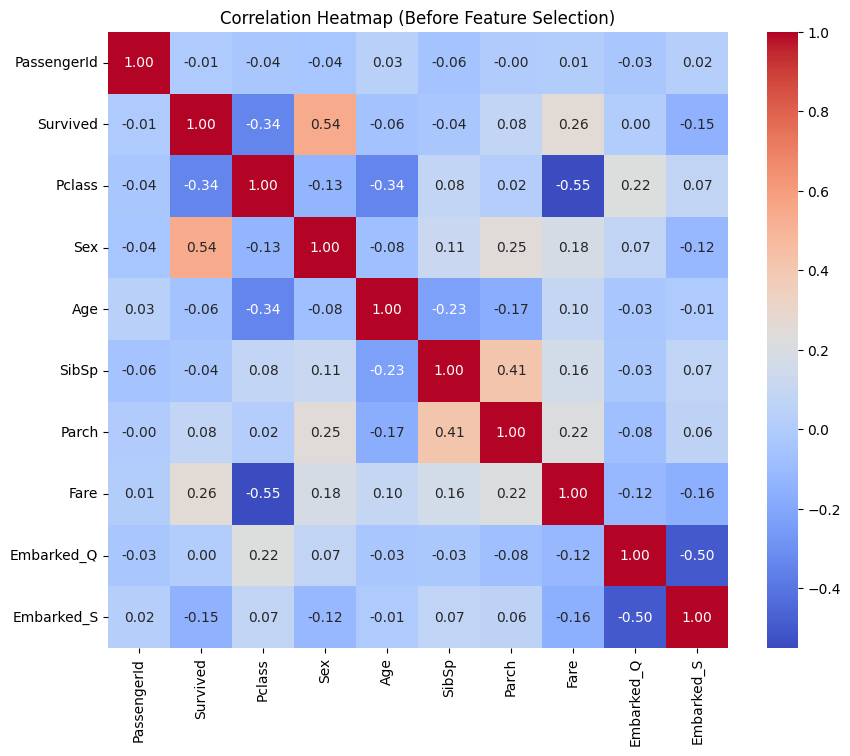

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Before Feature Selection)")
plt.show()

In [ ]:
#Feature Selection
features = ['Pclass', 'Sex', 'Parch', 'Fare', 'Embarked_S'] #BASED ONLY ON THE SURVIVED CLASS!!!
#DROPPING ALL THE 'FEATURES' WHO'S CORRELATION IS IN THE RANGE (0.08) > x > (-0.08)
X = data[features]
y = data['Survived']


In [34]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# =============================
# 7. Train Models
# =============================

# Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_val)
print("\nDecision Tree Accuracy:", accuracy_score(y_val, y_pred_dt))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))




Decision Tree Accuracy: 0.8044692737430168
Random Forest Accuracy: 0.7988826815642458


In [35]:
test = pd.read_csv("test.csv")

In [36]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [38]:
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [39]:
test['Age'].fillna(test['Age'].median(), inplace=True)
test.drop(columns=["Cabin", "Name"], inplace=True)

C:\Users\soumy\AppData\Local\Temp\ipykernel_16460\1437950310.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Age'].fillna(test['Age'].median(), inplace=True)


In [42]:
test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,male,34.5,0,0,330911,7.8292,Q
1,893,3,female,47.0,1,0,363272,7.0000,S
2,894,2,male,62.0,0,0,240276,9.6875,Q
3,895,3,male,27.0,0,0,315154,8.6625,S
4,896,3,female,22.0,1,1,3101298,12.2875,S


In [43]:
#repeating the same process
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)



In [44]:
#Cross validtion 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_dt = cross_val_score(dt, X, y, cv=kf, scoring='accuracy')
cv_rf = cross_val_score(rf, X, y, cv=kf, scoring='accuracy')

print("\nDecision Tree CV Accuracies:", cv_dt)
print("Decision Tree Avg:", cv_dt.mean())
print("\nRandom Forest CV Accuracies:", cv_rf)
print("Random Forest Avg:", cv_rf.mean())

#Chossng best model
best_model = rf if cv_rf.mean() > cv_dt.mean() else dt

#predicting on test data 
X_test = test[features]
test_predictions = best_model.predict(X_test)




Decision Tree CV Accuracies: [0.80446927 0.78651685 0.82022472 0.79775281 0.8258427 ]
Decision Tree Avg: 0.8069612704789405

Random Forest CV Accuracies: [0.7877095  0.78651685 0.85955056 0.79213483 0.8258427 ]
Random Forest Avg: 0.8103508882053857


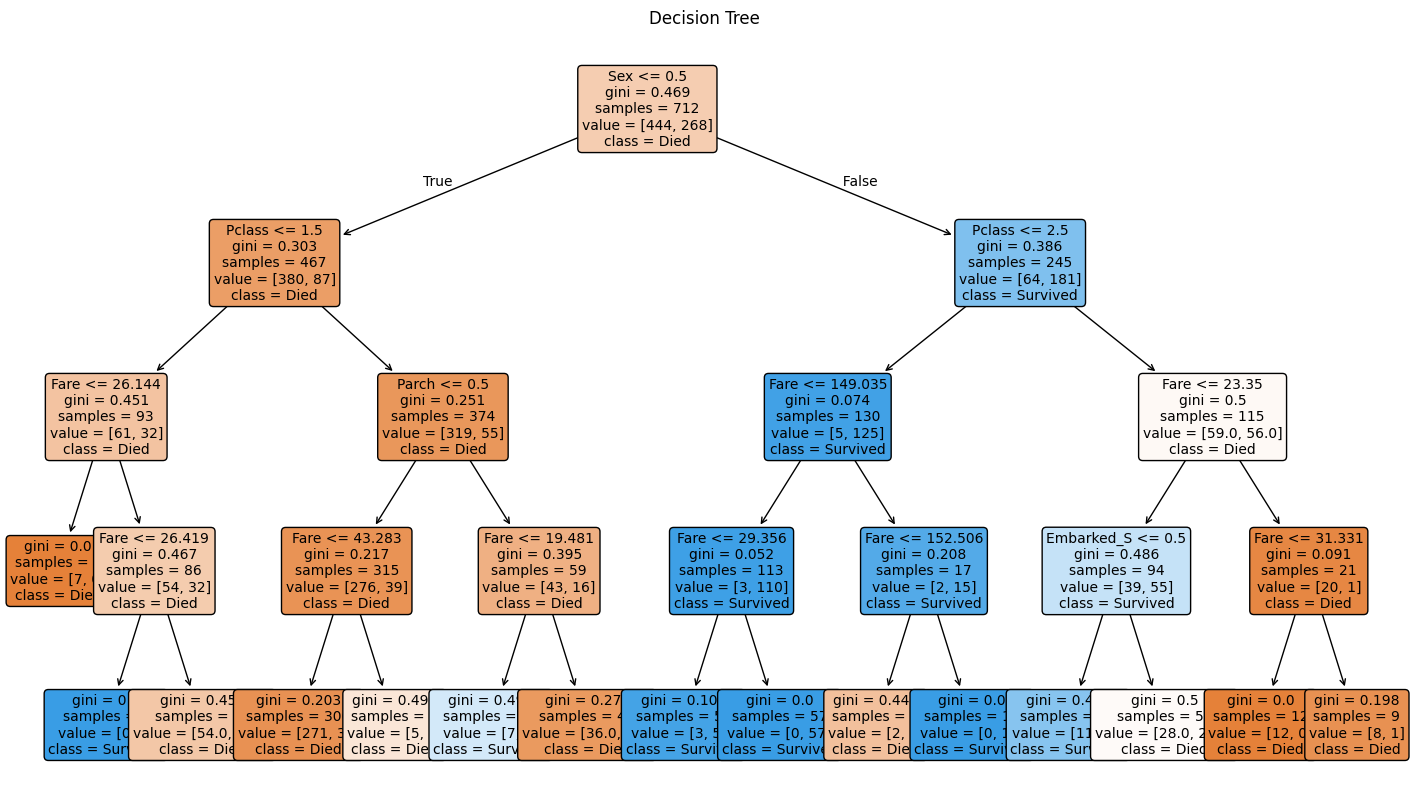

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
plot_tree(
    dt,
    filled=True,
    feature_names=features,
    class_names=["Died", "Survived"],
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree ")
plt.show()


In [47]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})
submission.to_csv("submission.csv", index=False)
print("\n submission.csv file created successfully!")


 submission.csv file created successfully!
